In [5]:
from typing import Optional
import torch
from torch import nn
from torchaudio import functional as F

class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # STFT parameters
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.pad_mode = pad_mode
        self.power = power
        self.normalize_stft = normalize_stft
        self.onesided = onesided
        self.center = center
        self.return_complex = return_complex

        # If f_max_hz is not provided, default to the Nyquist frequency.
        if f_max_hz is None:
            f_max_hz = samplerate / 2
        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        # Create a Hann window for STFT.
        self.window_length = n_fft
        # register_buffer ensures the window is moved along with the module's device.
        self.register_buffer("window", torch.hann_window(self.window_length))

        # Initialize mel filter banks
        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        # Calculate number of frequency bins.
        n_freqs = self.n_fft // 2 + 1 if self.onesided else self.n_fft
        # Build mel filter banks using torchaudio functional.
        return F.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale
        )

    def spectrogram(self, x):
        """
        Compute the complex STFT of input x.
        Args:
            x (torch.Tensor): Input tensor of shape (batch, time)
        Returns:
            torch.Tensor: Complex tensor of shape (batch, n_freq, n_frames)
        """
        return torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=self.window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )


    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Tensor of audio of dimension (batch, time)
        Returns:
            torch.Tensor: Log mel filterbanks of dimension (batch, n_mels, n_frames)
        """
        #STFT
        spec = self.spectrogram(x)
        # Если форма не соответствует (batch, n_freq, n_frames), попробуем транспонировать оси
        # (иногда torch.stft возвращает (batch, n_frames, n_freq))
        if spec.dim() == 3 and spec.shape[1] != self.mel_fbanks.shape[1] and spec.shape[2] == self.mel_fbanks.shape[1]:
            spec = spec.transpose(1, 2)

        # Вычисляем power спектр
        spec_power = spec.abs() ** self.power  # (batch, n_freq, n_frames)

        # Отладочный вывод форм
        print("spec_power.shape =", spec_power.shape)         # ожидаем (batch, n_freq, n_frames)
        print("self.mel_fbanks.shape =", self.mel_fbanks.shape)   # ожидаем (n_mels, n_freq) или (n_freq, n_mels)

        # Если mel-фильтры имеют форму (n_freq, n_mels), то транспонируем их
        if self.mel_fbanks.shape[0] != self.n_mels:
            mel_fbanks = self.mel_fbanks.t()  # теперь должна быть (n_mels, n_freq)
        else:
            mel_fbanks = self.mel_fbanks

        # Проверим, что размерность по частотной оси совпадает
        # spec_power имеет размер n_freq в оси 1, а mel_fbanks должна иметь n_freq в оси 1
        assert spec_power.shape[1] == mel_fbanks.shape[1], \
            f"Mismatch: spec_power.shape[1]={spec_power.shape[1]}, mel_fbanks.shape[1]={mel_fbanks.shape[1]}"

        # Теперь выполняем умножение с помощью einsum:
        # mel_fbanks: (n_mels, n_freq), spec_power: (batch, n_freq, n_frames)
        # Результат: (batch, n_mels, n_frames)
        mel_spec = torch.einsum("mf,bfn->bmn", mel_fbanks, spec_power)

        return torch.log(mel_spec + 1e-6)







In [6]:
import torchaudio
signal, sr = torchaudio.load("test.wav")

melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)

logmelbanks = LogMelFilterBanks()(signal)

assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks, atol=1e-4)



spec_power.shape = torch.Size([2, 201, 1364])
self.mel_fbanks.shape = torch.Size([201, 80])


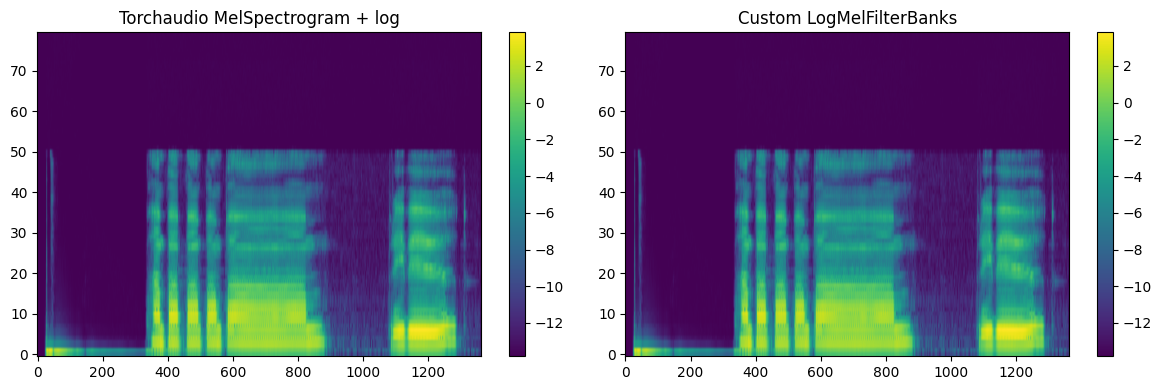

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Torchaudio MelSpectrogram + log")
plt.imshow(torch.log(melspec[0] + 1e-6).numpy(), aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Custom LogMelFilterBanks")
plt.imshow(logmelbanks[0].detach().numpy(), aspect='auto', origin='lower')

plt.colorbar()

plt.tight_layout()
plt.show()
